# Regression Models Implementation

## Objective
This section applies regression models to predict the probability of stress in Reddit posts.

The dataset contains:
- Text data (`text_clean`)
- Binary labels (`label`)
- Engineered numerical features (text length, word count, etc.)

A hybrid approach is used combining textual and numerical features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge

from sklearn.metrics import mean_squared_error, r2_score
from scipy.sparse import hstack, csr_matrix

In [2]:
df = pd.read_csv("cleaned_data_set.csv")

df.head()

,text,subreddit,label,text_len,word_len,sentence_count,log_text_len,log_word_len,text_clean
0,he said he had not felt that way before sugget...,ptsd,1,571,113,11,6.349139,4.736198,said felt way suggeted go rest trigger ahead y...
1,hey there rassistance not sure if this is the ...,assistance,0,588,108,5,6.378426,4.691348,hey rassistance sure right place post goes im ...
2,my mom then hit me with the newspaper and it s...,ptsd,1,847,166,5,6.742881,5.117994,mom hit newspaper shocked would knows dont lik...
3,until i met my new boyfriend he is amazing he ...,relationships,1,1277,273,7,7.153052,5.613128,met new boyfriend amazing kind sweet good stud...
4,october is domestic violence awareness month a...,survivorsofabuse,1,533,89,5,6.280396,4.499810,october domestic violence awareness month dome...


## Data Formatting for Models

| Step | Transformation | Reason |
|------|--------------|--------|
| Text Cleaning | Normalize and clean text | Improve TF-IDF representation |
| TF-IDF | Convert text → numeric vectors | Required for ML models |
| Scaling | Standardize numeric features | Prevent dominance of large values |
| Sparse Conversion | Convert numeric to sparse | Compatible with TF-IDF |
| Feature Combination | Merge text + numeric | Improve predictive performance |

In [3]:
# ===== FORCE CLEAN DATA (PATCH FIX) =====

# Fix column names
df.columns = df.columns.str.strip()

# Convert label
df['label'] = pd.to_numeric(df['label'], errors='coerce')

# Convert numeric features
numeric_cols = ['text_len', 'word_len', 'sentence_count',
                'log_text_len', 'log_word_len']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fix text
df['text_clean'] = df['text_clean'].astype(str)

# Drop bad rows
df = df.dropna()
df = df[df['text_clean'].str.len() > 10]

df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)

Cleaned shape: (57506, 9)


## Data Cleaning

- Converted labels to numeric format
- Removed missing values
- Filtered out very short text entries
- Reset index to maintain alignment

In [4]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
1    52045
0     5461
Name: count, dtype: int64
label
1    0.905036
0    0.094964
Name: proportion, dtype: float64


### Class Imbalance Observation

The dataset is highly imbalanced, with approximately 90% of posts labeled as stressed.

To address this, class weighting is used in Logistic Regression to prevent bias toward the majority class.

## Feature Preparation

- Text data is transformed using TF-IDF
- Numerical features are standardized
- Both feature types are combined for modeling

In [5]:
text_data = df['text_clean']

numeric_features = df[['text_len', 'word_len', 'sentence_count',
                       'log_text_len', 'log_word_len']]

y = df['label']

In [6]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    text_data,
    numeric_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


### Before Transformation Snapshot

In [8]:
print("Sample raw text:")
print(X_train_text.iloc[0])

print("\nTF-IDF vector shape:", X_train_tfidf.shape)

Sample raw text:
1 father would abuse consistently mentally physically think 4 14 maybe earlier dont really remember brought often school related remember car seat mother didnt know took parents apart tried run knew going happen remember crying hard hyperventilated mom promised never hed grades misbehaved

TF-IDF vector shape: (46004, 5000)


In [9]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)



In [10]:
print("\nBefore scaling (numeric):")
print(X_train_num.iloc[0])

print("\nAfter scaling (numeric):")
print(X_train_num_scaled[0])


Before scaling (numeric):
text_len          501.000000
word_len           96.000000
sentence_count      5.000000
log_text_len        6.218600
log_word_len        4.574711
Name: 2116, dtype: float64

After scaling (numeric):
[-0.06002151 -0.06228768 -0.23222912  0.38954945  0.38438653]


### After Transformation Snapshot

In [11]:
X_train_num_sparse = csr_matrix(X_train_num_scaled)
X_test_num_sparse = csr_matrix(X_test_num_scaled)

X_train_final = hstack([X_train_tfidf, X_train_num_sparse])
X_test_final = hstack([X_test_tfidf, X_test_num_sparse])

print("Final shape:", X_train_final.shape)

Final shape: (46004, 5005)


### Data Transformation

Before transformation, the dataset consists of raw text and numerical features.

After preprocessing:
- Text data is converted into TF-IDF vectors representing word importance
- Numerical features are standardized to ensure equal contribution

This transformation ensures compatibility with machine learning models and improves model performance.

## Model 1: Logistic Regression

### Why chosen
- Suitable for binary targets
- Outputs probability values
- Works well with high-dimensional data

### Assumptions
- Linear relationship with log-odds
- Independent observations

### Hyperparameter tuning
GridSearchCV is used to optimize regularization strength

In [12]:
param_grid = {'C': [0.1, 1, 10]}

log_model = LogisticRegression(max_iter=2000, class_weight='balanced')

grid = GridSearchCV(log_model, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_final, y_train)

best_log_model = grid.best_estimator_

A small grid of hyperparameter values was used to balance computational cost and performance.

In [13]:
y_pred_prob = best_log_model.predict_proba(X_test_final)[:, 1]

mse_log = mean_squared_error(y_test, y_pred_prob)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_prob)

print("Logistic RMSE:", rmse_log)
print("MSE:", mse_log)
print("R2 Score:", r2_log)

Logistic RMSE: 0.21834585392103464
MSE: 0.047674911924505806
R2 Score: 0.4451657554316901


In [14]:
print("Predicted mean:", y_pred_prob.mean())
print("Actual mean:", y_test.mean())
print("Difference:", abs(y_pred_prob.mean() - y_test.mean()))

Predicted mean: 0.854401387505751
Actual mean: 0.9050599895670318
Difference: 0.05065860206128081


### Calibration Insight

The predicted mean (0.854) is lower than the actual mean (0.905), indicating that the model underestimates stress probability.

This gap suggests bias toward underprediction, likely due to class imbalance, even though class weighting is applied.

In [15]:
feature_names = list(tfidf.get_feature_names_out()) + list(numeric_features.columns)

coefficients = best_log_model.coef_[0]

top_features = sorted(
    zip(feature_names, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)[:15]

print("Top Influential Features:")
for f, c in top_features:
    print(f, ":", c)

Top Influential Features:
deleted : 29.742720390153863
depression : 22.995919799764795
bipolar : 14.852137700859407
url : -12.192706059767767
die : 11.468437459862017
removed : 11.267160413071267
suicidal : 11.013441413925191
kill : 10.623680690279485
suicide : 10.099485061345028
text_len : -9.682487894684911
word_len : 9.657194298526173
manic : 9.513998465222045
occasions : -9.311820221830478
depressed : 9.073633519416964
ptsd : -8.97568477187901


### Feature Importance Interpretation

Words such as "depression", "suicidal", and "bipolar" strongly increase the likelihood of stress classification, reflecting clear psychological indicators.

Negative coefficients (e.g., "url") suggest non-emotional or informational content reduces stress likelihood.

Numerical features like word length and text length also influence predictions, indicating that longer posts tend to contain more expressive or stress-related content.

## Model 2: Ridge Regression

### Why chosen
- Handles high-dimensional data better than linear regression
- Uses L2 regularization to prevent overfitting

### Assumptions
- Linear relationship
- Requires feature scaling

In [16]:
param_grid = {'alpha': [0.1, 1, 10]}

ridge = Ridge()

grid_ridge = GridSearchCV(ridge, param_grid, cv=5)
grid_ridge.fit(X_train_final, y_train)

best_ridge = grid_ridge.best_estimator_

y_pred_ridge = best_ridge.predict(X_test_final)
y_pred_ridge = np.clip(y_pred_ridge, 0, 1)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)

Ridge RMSE: 0.2124571694431233
MSE: 0.045138048847783996
R2 Score: 0.4746894284061688


### Challenges & Solutions

- Class imbalance (~90% stressed) → handled using class_weight  
- High dimensional TF-IDF → handled using Ridge regularization  
- Different feature scales → handled using StandardScaler  
- Sparse + dense mix → converted numeric to sparse

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Ridge Regression'],
    'RMSE': [rmse_log, rmse_ridge],
    'R2 Score': [r2_log, r2_ridge]
})

results

,Model,RMSE,R2 Score
0,Logistic Regression,0.218346,0.445166
1,Ridge Regression,0.212457,0.474689


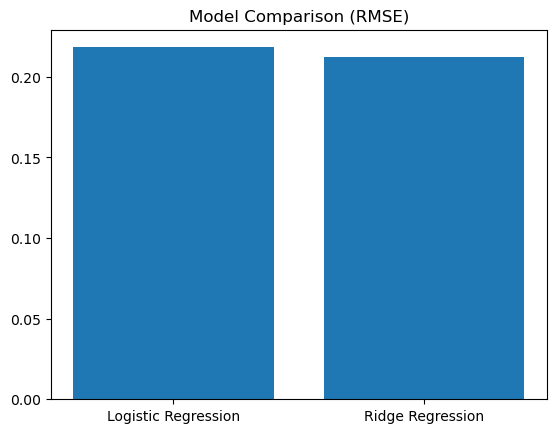

In [18]:
plt.bar(results['Model'], results['RMSE'])
plt.title("Model Comparison (RMSE)")
plt.show()

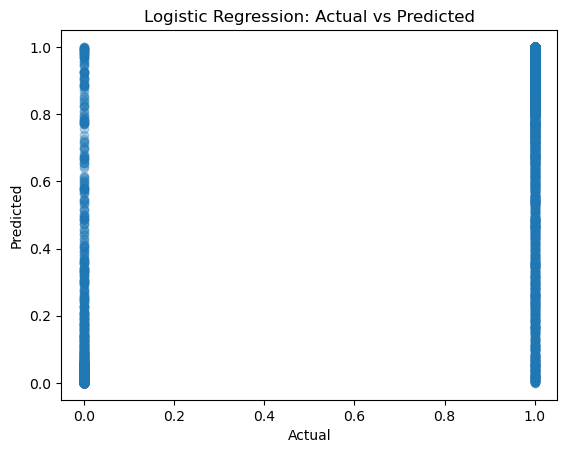

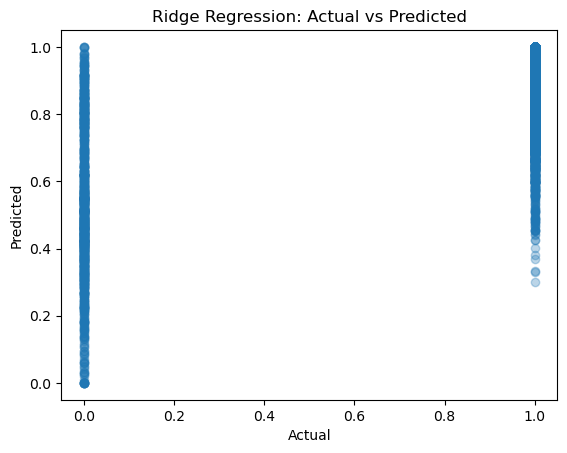

In [19]:
# Logistic
plt.scatter(y_test, y_pred_prob, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Logistic Regression: Actual vs Predicted")
plt.show()

# Ridge
plt.scatter(y_test, y_pred_ridge, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

## Model Comparison

- Ridge performs better (RMSE 0.212 vs 0.218, R² 0.47 vs 0.44) indicating better predictive performance. 
- Logistic Regression remains more appropriate conceptually due to its probabilistic interpretation for binary targets.
- Despite Ridge performing slightly better numerically, Logistic Regression is preferred for interpretability and alignment with the problem type.

## Conclusion

The dataset is highly imbalanced (~90% stressed posts), significantly influencing model behavior.

Ridge Regression achieves better numerical performance, but Logistic Regression is more suitable for interpreting stress probability due to its probabilistic framework.

Both textual features and structural characteristics contribute meaningfully to prediction, demonstrating the importance of combining multiple feature types in text-based analysis.